In [1]:
import sys
import os
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Make model/ and parameter_scan/ importable (if running from parameter_scan/)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('../.'))

In [2]:
import numpy as np
import time
import xso
import xso.solvers as _solvers
from np_setups import (
    model_open, model_npz_typeII, model_npz_typeIII,
    model_setup_open_const,
    model_setup_npz_typeII_matched,
    model_setup_npz_typeII_omni,
    model_setup_npz_typeIII_matched,
)

DIAG = {'runs': []}
_real_solve_ivp = _solvers.solve_ivp

def _diag_solve_ivp(fun, t_span, y0, **kwargs):
    """Wrap solve_ivp: record every RHS-evaluation time and capture sol."""
    times = []
    def traced(t, y, *a, **kw):
        times.append(float(t))
        return fun(t, y, *a, **kw)
    t0 = time.time()
    sol = _real_solve_ivp(traced, t_span, y0, **kwargs)
    DIAG['runs'].append({
        'method'      : kwargs.get('method', 'RK45'),
        't_span'      : tuple(t_span),
        'fun'         : fun,                          # raw f(t, y), kept for Jacobian
        'y0'          : np.asarray(y0).copy(),
        'sol'         : sol,
        'call_times'  : np.array(times),
        'wall_time_s' : time.time() - t0,
        'nfev'        : sol.nfev,
        'success'     : sol.success,
        'message'     : sol.message,
    })
    return sol

_solvers.solve_ivp = _diag_solve_ivp

def diag_reset():
    DIAG['runs'].clear()

def diag_summary():
    print(f"{'method':<8s} {'T (d)':>7s} {'wall (s)':>10s} "
          f"{'nfev':>10s} {'nfev/d':>10s}")
    print('-' * 50)
    for r in DIAG['runs']:
        T = r['t_span'][1] - r['t_span'][0]
        print(f"{r['method']:<8s} {T:>7.0f} {r['wall_time_s']:>10.2f} "
              f"{r['nfev']:>10d} {r['nfev']/T:>10.1f}")

In [3]:
diag_reset()

SHORT_T = 200
short_time = np.arange(0, SHORT_T, 1)
base_kwargs = {'method': 'LSODA', 'atol': 1e-6, 'rtol': 1e-4,
               'instability_neg_threshold': -1e-3}

short_setup = xso.update_setup(
    model            = model_npz_typeII,
    old_setup        = model_setup_npz_typeII_matched,
    new_solver       = 'solve_ivp',
    new_time         = short_time,
    new_solver_kwargs= base_kwargs,
)
with model_npz_typeII:
    _ = short_setup.xsimlab.run()

diag_summary()

short_nfev_per_day = DIAG['runs'][-1]['nfev'] / SHORT_T
full_nfev_per_day  = 8282799 / 5000
print(f"\n  short-window nfev/d : {short_nfev_per_day:.1f}")
print(f"  full-run    nfev/d : {full_nfev_per_day:.1f}")
print(f"  ratio short/full   : {short_nfev_per_day/full_nfev_per_day:.2f}")
print("  >1.5  → cost concentrates in the early transient")
print("  ~1.0  → cost is uniform → sustained oscillation/floor tracking")
print("  <0.5  → cost concentrates late → noise-floor / atol-driven")

KeyboardInterrupt: 

  raw RHS calls captured : 133987
  sol.nfev               : 133987
  (the two differ because solve_ivp interrogates fun at trial/stage points too; the histogram still shows where work lives.)


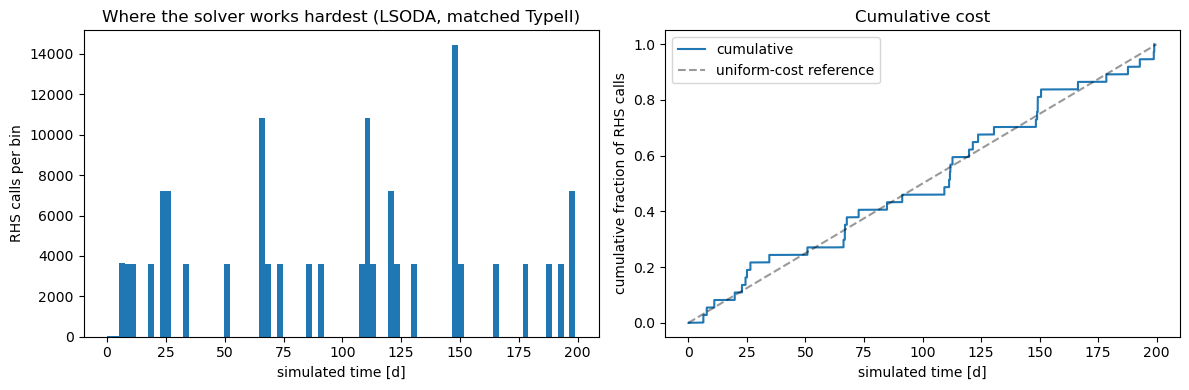

In [5]:
import matplotlib.pyplot as plt

times = DIAG['runs'][-1]['call_times']
print(f"  raw RHS calls captured : {len(times)}")
print(f"  sol.nfev               : {DIAG['runs'][-1]['nfev']}")
print("  (the two differ because solve_ivp interrogates fun at "
      "trial/stage points too; the histogram still shows where work lives.)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(times, bins=80)
ax[0].set_xlabel('simulated time [d]')
ax[0].set_ylabel('RHS calls per bin')
ax[0].set_title('Where the solver works hardest (LSODA, matched TypeII)')

sorted_t = np.sort(times)
ax[1].plot(sorted_t, np.arange(len(sorted_t)) / len(sorted_t),
           label='cumulative')
ax[1].plot([0, SHORT_T], [0, 1], 'k--', alpha=0.4,
           label='uniform-cost reference')
ax[1].set_xlabel('simulated time [d]')
ax[1].set_ylabel('cumulative fraction of RHS calls')
ax[1].set_title('Cumulative cost')
ax[1].legend()
plt.tight_layout(); plt.show()

In [6]:
diag_reset()

for method in ['LSODA', 'BDF', 'Radau']:
    kw = {'method': method, 'atol': 1e-6, 'rtol': 1e-4,
          'instability_neg_threshold': -1e-3}
    s = xso.update_setup(
        model            = model_npz_typeII,
        old_setup        = model_setup_npz_typeII_matched,
        new_solver       = 'solve_ivp',
        new_time         = short_time,
        new_solver_kwargs= kw,
    )
    print(f"  Running matched TypeII, method={method}, 0-{SHORT_T} d ...")
    with model_npz_typeII:
        _ = s.xsimlab.run()

print()
diag_summary()
print("\n  If BDF/Radau cut nfev by >10x with similar wall time, "
      "LSODA is staying in Adams mode and a stiff method is the answer.")
print("  If all three are within 2x of each other, the system isn't "
      "classically stiff and the cost is genuinely oscillatory.")

  Running matched TypeII, method=LSODA, 0-200 d ...
  Running matched TypeII, method=BDF, 0-200 d ...
  Running matched TypeII, method=Radau, 0-200 d ...

method     T (d)   wall (s)       nfev     nfev/d
--------------------------------------------------
LSODA        199      63.22     133987      673.3
BDF          199      71.34        432        2.2
Radau        199     190.31        674        3.4

  If BDF/Radau cut nfev by >10x with similar wall time, LSODA is staying in Adams mode and a stiff method is the answer.
  If all three are within 2x of each other, the system isn't classically stiff and the cost is genuinely oscillatory.


In [7]:
import scipy.linalg

def jac_fd(fun, y, t=0.0, eps_rel=1e-6, eps_abs=1e-10):
    """Forward-difference Jacobian. n^2 RHS calls — fine for n~80."""
    n  = len(y)
    f0 = np.asarray(fun(t, y))
    J  = np.zeros((n, n))
    for i in range(n):
        eps = eps_rel * abs(y[i]) + eps_abs
        yi = y.copy()
        yi[i] += eps
        J[:, i] = (np.asarray(fun(t, yi)) - f0) / eps
    return J

def stiffness_report(label, fun, y, t=0.0):
    J = jac_fd(fun, y, t=t)
    eigs = scipy.linalg.eigvals(J)
    re = np.real(eigs)
    # Drop the trivial 0 eigenvalue from the time-pseudo-variable row
    nontrivial = np.abs(re) > 1e-12
    lam_max = np.max(np.abs(re[nontrivial]))
    lam_min = np.min(np.abs(re[nontrivial]))
    osc = np.max(np.abs(np.imag(eigs))) / max(lam_max, 1e-30)
    print(f"\n  {label}")
    print(f"    state size n            : {len(y)}")
    print(f"    |Re λ|_max              : {lam_max:.4g} d^-1   "
          f"(fastest mode ~ {1.0/lam_max:.3g} d)")
    print(f"    |Re λ|_min              : {lam_min:.4g} d^-1   "
          f"(slowest mode ~ {1.0/lam_min:.3g} d)")
    print(f"    stiffness ratio         : {lam_max/lam_min:.3g}")
    print(f"    max |Im λ| / max |Re λ| : {osc:.3g}")
    print("      >>1 → oscillation-dominated;  ~1 → decay-dominated")
    return J, eigs

# Use the LSODA run captured in cell 4 (slow case).
matched_lsoda = next(r for r in DIAG['runs'] if r['method'] == 'LSODA')
stiffness_report("TypeII matched, near final IVP state",
                 matched_lsoda['fun'], matched_lsoda['sol'].y[:, -1])

# Now run NP-only as a fast-variant baseline, then analyse the same way.
diag_reset()
np_setup = xso.update_setup(
    model            = model_open,
    old_setup        = model_setup_open_const,
    new_solver       = 'solve_ivp',
    new_time         = short_time,
    new_solver_kwargs= {'method': 'LSODA', 'atol': 1e-6, 'rtol': 1e-4,
                        'instability_neg_threshold': -1e-3},
)
with model_open:
    _ = np_setup.xsimlab.run()
np_run = DIAG['runs'][-1]
stiffness_report("NP-only (open chemostat), near final IVP state",
                 np_run['fun'], np_run['sol'].y[:, -1])


  TypeII matched, near final IVP state
    state size n            : 3608
    |Re λ|_max              : 8.84 d^-1   (fastest mode ~ 0.113 d)
    |Re λ|_min              : 0.002649 d^-1   (slowest mode ~ 378 d)
    stiffness ratio         : 3.34e+03
    max |Im λ| / max |Re λ| : 0.0152
      >>1 → oscillation-dominated;  ~1 → decay-dominated

  NP-only (open chemostat), near final IVP state
    state size n            : 166
    |Re λ|_max              : 19.1 d^-1   (fastest mode ~ 0.0523 d)
    |Re λ|_min              : 0.01421 d^-1   (slowest mode ~ 70.4 d)
    stiffness ratio         : 1.34e+03
    max |Im λ| / max |Re λ| : 0
      >>1 → oscillation-dominated;  ~1 → decay-dominated


(array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00, -1.91545720e+01, -5.05371413e-02, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  1.85212085e+01,  5.37141253e-04, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],
       shape=(166, 166)),
 array([ 0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e

In [21]:
import scipy.integrate as _scipy_int
import xso.solvers as _solvers
_solvers.solve_ivp = _scipy_int.solve_ivp

In [22]:
# Benchmark: naive default RK45 (solver='solve_ivp') on matched-Type-II.
#
# Verifies both stiffness diagnostics on a stiff model with default kwargs:
#   - in-run alert mid-integration  (UserWarning "at this rate ...")
#   - post-run warning at end       (UserWarning "step controller is working hard")
#
# inrun_alert_threshold is lowered below the 1_000_000 production default
# so the alert fires within the short test horizon — at scipy's default
# atol/rtol, matched-Type-II's RK45 burns ~3k–5k nfev/sim-day in the early
# transient, so a 50k budget at 200 d horizon projects to >>50k and fires
# at the first 10k-call check (a few seconds of wall time).

import time
import warnings as _warnings
import numpy as np
import xso
import xso.solvers as _solvers

from np_setups import (
    model_npz_typeII,
    model_setup_npz_typeII_matched,
)

F_N_ANCHOR = 15.0
SHORT_T = 200
short_time = np.arange(0, SHORT_T, 1)

# Re-arm the once-per-process diagnostic flags so we see fresh warnings.
_solvers.IVPSolver._nfev_warned = False
_solvers.IVPSolver._inrun_warned = False

# Build a "naive RK45" setup. By NOT passing 'method' or 'rtol' or 'atol'
# in new_solver_kwargs, we fall back to IVPSolver class defaults
# (rtol=1e-6, atol=1e-9) and scipy's own default method=RK45.
# Kept: instability_neg_threshold=-1e-3 (so Type-II overshoots don't
# instakill the run before the stiffness diagnostics get a chance).
# Lowered: inrun_alert_threshold so the alert fires within this window.
naive_setup = xso.update_setup(
    model            = model_npz_typeII,
    old_setup        = model_setup_npz_typeII_matched,
    new_solver       = 'solve_ivp',
    new_time         = short_time,
#    new_solver_kwargs= {
#        'instability_neg_threshold': -1e-3,
#        'inrun_alert_threshold'    : 50_000,
#    },
)

print(f"Running matched-Type-II with naive scipy defaults "
      f"(solver='solve_ivp', RK45, rtol=1e-6, atol=1e-9), "
      f"F_N={F_N_ANCHOR}, 0-{SHORT_T} d ...")
print(f"  in-run alert threshold lowered to 50k (production default is 1M)\n")

captured = []
t0 = time.time()
with _warnings.catch_warnings(record=True) as caught:
    _warnings.simplefilter('always')
    with model_npz_typeII:
        out = (naive_setup
               .xsimlab.update_vars(input_vars={'FN_Forcing': {'value': F_N_ANCHOR}})
               .xsimlab.run())
    for w in caught:
        msg = str(w.message)
        if 'at this rate' in msg or 'step controller is working hard' in msg:
            captured.append((w.category.__name__, msg))
wall = time.time() - t0

print(f"=== Naive RK45 on matched-Type-II, 0-{SHORT_T} d ===")
print(f"  wall time : {wall:.1f} s\n")

if captured:
    for i, (cat, msg) in enumerate(captured, start=1):
        label = "IN-RUN alert" if 'at this rate' in msg else "POST-RUN warning"
        print(f"  [{i}] {label}  ({cat})")
        print(f"      {msg}\n")
else:
    print("  No stiffness diagnostics fired — paste the output and we'll check.")

Running matched-Type-II with naive scipy defaults (solver='solve_ivp', RK45, rtol=1e-6, atol=1e-9), F_N=15.0, 0-200 d ...
  in-run alert threshold lowered to 50k (production default is 1M)

=== Naive RK45 on matched-Type-II, 0-200 d ===
  wall time : 4.7 s

  No stiffness diagnostics fired — paste the output and we'll check.


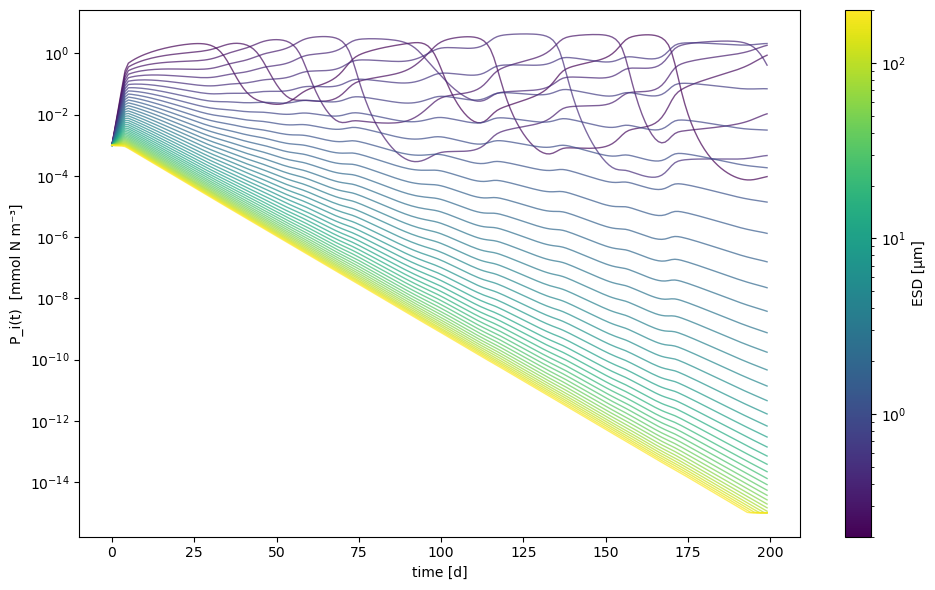

In [23]:
#out.Phytoplankton__biomass.plot(x='time')
from np_setups import (
    phyto_esd, n_classes,
    model_closed, model_open,
    model_setup_closed_const,   model_setup_closed_const_stability,
    model_setup_closed_allom,   model_setup_closed_allom_stability,
    model_setup_open_const,     model_setup_open_const_stability,
    model_setup_open_allom,     model_setup_open_allom_stability,
)
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

P_t = out.Phytoplankton__biomass.transpose('time', 'phyto').values
t   = out.time.values
ess = out.phyto.values

fig, ax = plt.subplots(figsize=(10, 6))
norm = mcolors.LogNorm(vmin=ess.min(), vmax=ess.max())
cmap = plt.get_cmap('viridis')
for i in range(n_classes):
    ax.plot(t, np.maximum(P_t[:, i], 1e-15),
            color=cmap(norm(ess[i])), alpha=0.7, lw=1)
ax.set_yscale('log')
ax.set_xlabel('time [d]')
ax.set_ylabel('P_i(t)  [mmol N m⁻³]')

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
plt.colorbar(sm, ax=ax, label='ESD [µm]')
plt.tight_layout()
plt.show()

In [24]:
import time, warnings as _warnings, logging
import numpy as np
import xso, xso.solvers as _solvers
from np_setups import model_npz_typeII, model_setup_npz_typeII_matched

F_N_ANCHOR = 15.0
FULL_T = 5000
full_time = np.arange(0, FULL_T, 1)

_solvers.IVPSolver._nfev_warned = False
_solvers.IVPSolver._inrun_warned = False
logging.getLogger('xso.solvers').setLevel(logging.INFO)
logging.basicConfig(level=logging.INFO, format='%(name)s: %(message)s', force=True)

naive_setup = xso.update_setup(
    model            = model_npz_typeII,
    old_setup        = model_setup_npz_typeII_matched,
    new_solver       = 'solve_ivp',
    new_time         = full_time,
    new_solver_kwargs= {
        'instability_neg_threshold': -1e-3,
        'trace_steps'              : True,
    },
)

print(f"Naive RK45 on FULL matched-Type-II, F_N={F_N_ANCHOR}, 0-{FULL_T} d ...")
print(f"  production defaults: in-run alert fires at projected total > 1M nfev.\n")

t0 = time.time()
with _warnings.catch_warnings(record=True) as caught:
    _warnings.simplefilter('always')
    with model_npz_typeII:
        out = (naive_setup
               .xsimlab.update_vars(input_vars={'FN_Forcing': {'value': F_N_ANCHOR}})
               .xsimlab.run())
wall = time.time() - t0

print(f"\n=== Naive RK45, 0-{FULL_T} d ===")
print(f"  wall time : {wall:.1f} s")

stiff_warnings = [
    w for w in caught
    if 'at this rate' in str(w.message) or 'step controller is working hard' in str(w.message)
]
if stiff_warnings:
    for w in stiff_warnings:
        label = "IN-RUN alert" if 'at this rate' in str(w.message) else "POST-RUN warning"
        print(f"\n  {label}:\n      {w.message}")
else:
    print("\n  No stiffness diagnostics fired — naive RK45 handled this quietly.")

Naive RK45 on FULL matched-Type-II, F_N=15.0, 0-5000 d ...
  production defaults: in-run alert fires at projected total > 1M nfev.


=== Naive RK45, 0-5000 d ===
  wall time : 132.4 s

  No stiffness diagnostics fired — naive RK45 handled this quietly.
